 # Practice — Try These
 Exercise 1: Build a Decision Tree model with max_depth=3. Print accuracy and classification report.

Exercise 2: Visualize the decision tree. What is the first question it asks?

Exercise 3: Print feature importance. Which feature matters more — Age or Salary?

Exercise 4: Build a Random Forest with 100 trees on the same data. Compare accuracy with Decision Tree.

Exercise 5: Predict whether someone aged 35 with salary 45000 will buy a car.

Exercise 6 (thinking): Why does Random Forest usually perform better than a single Decision Tree?


    Age  Salary  Bought_Car
0    22   25000           0
1    25   30000           0
2    47   52000           1
3    52   48000           1
4    46   51000           1
5    56   60000           1
6    55   58000           1
7    60   62000           1
8    62   65000           1
9    35   40000           0
10   38   42000           1
11   29   32000           0

             Age        Salary  Bought_Car
count  12.000000     12.000000   12.000000
mean   43.916667  47083.333333    0.666667
std    13.846288  13324.334084    0.492366
min    22.000000  25000.000000    0.000000
25%    33.500000  38000.000000    0.000000
50%    46.500000  49500.000000    1.000000
75%    55.250000  58500.000000    1.000000
max    62.000000  65000.000000    1.000000

before prediction: 10    1
9     0
0     0
Name: Bought_Car, dtype: int64

after prediction: [1 0 0]

Actual:    [1, 0, 0]
Predicted: [np.int64(1), np.int64(0), np.int64(0)]
Accuracy:  1.00

              precision    recall  f1-score   support

 

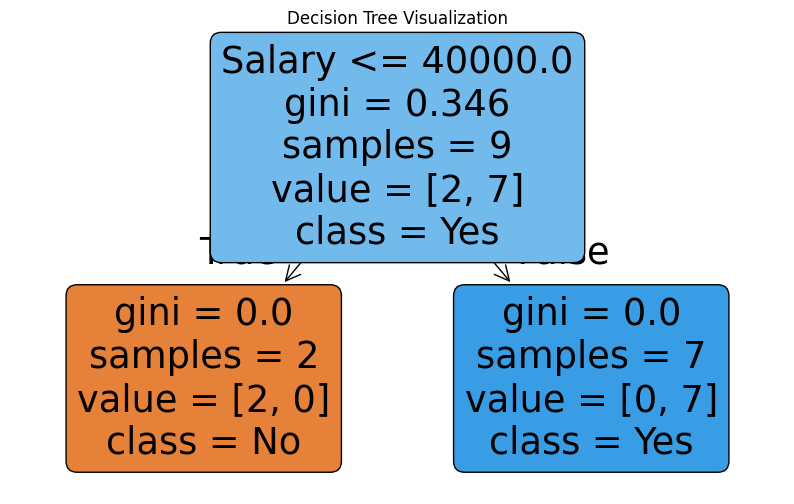

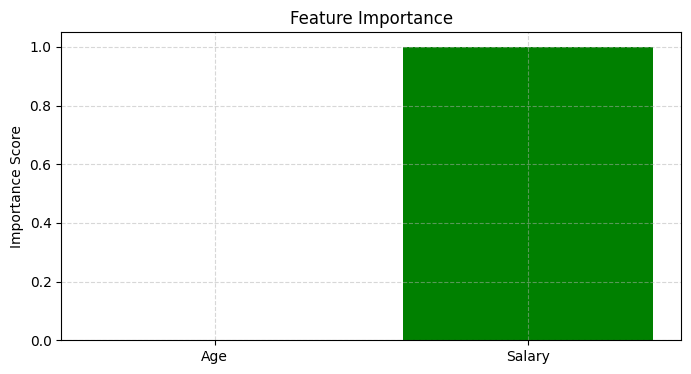

Age: 0.000
Salary: 1.000
   Age  Salary
0   35   45000
Prediction: [1]
Probability → No Car: 0.00, Buy Car: 1.00
yes, he can buy a car
Random Forest Accuracy: 1.00

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



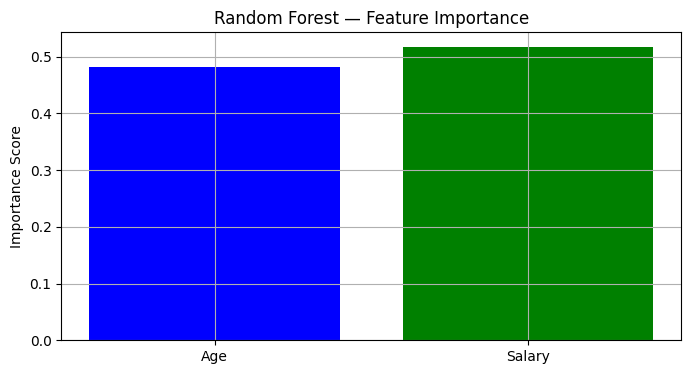

Age: 0.483
Salary: 0.517
Prediction by random forest: [1]
Probability → No Car: 0.42, Buy Car: 0.58


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
#task 1
data = {
    'Age':        [22, 25, 47, 52, 46, 56, 55, 60, 62, 35, 38, 29],
    'Salary':     [25000, 30000, 52000, 48000, 51000, 60000,
                   58000, 62000, 65000, 40000, 42000, 32000],
    'Bought_Car': [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0]  }

df=pd.DataFrame(data)
print(f'{df}\n')
print(f'{df.describe()}\n')

x=df[['Age','Salary']]
y=df['Bought_Car']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model=DecisionTreeClassifier(max_depth=3)
model.fit(x_train,y_train)

print(f'before prediction: {y_test}\n')
y_pred=model.predict(x_test)
print(f'after prediction: {y_pred}\n')

print(f'Actual:    {list(y_test)}')
print(f'Predicted: {list(y_pred)}')
print(f'Accuracy:  {accuracy_score(y_test,y_pred):.2f}')

#clasification report table
print(f'\n{classification_report(y_test,y_pred)}')

# Task 2 - visualization of decision tree
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=x.columns, class_names=['No','Yes'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
# plt.show()
# task 3
impt=model.feature_importances_
features=['Age','Salary']

# Bar Chart Plotting
plt.figure(figsize=(8, 4))
plt.bar(features, impt, color=['blue', 'green'])
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
for feat, importance_val in zip(features, impt):
    print(f'{feat}: {importance_val:.3f}')
# so it gives importance to age , which thoertically says that a person
# have more age is gonna have a car but from my perspective it is unfair , what about salary , it should be

# Task 5 prediction for new value
new_val=pd.DataFrame({'Age':[35],
                      'Salary':[45000]})
print(new_val)
new_pred=model.predict(new_val)
new_prob = model.predict_proba(new_val)

print(f'Prediction: {new_pred}')
print(f'Probability → No Car: {new_prob[0][0]:.2f}, Buy Car: {new_prob[0][1]:.2f}')


if(new_pred==1):
  print('yes, he can buy a car')
else:
  print('no')

# Task 4 Now with Random Forest Same data, same split — just different model!
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

print(f'Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.2f}')
print(f'\n{classification_report(y_test, rf_pred)}')

# Feature importance from Random Forest
rf_importance = rf_model.feature_importances_
plt.figure(figsize=(8, 4))
plt.bar(features, rf_importance, color=['blue', 'green'])
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance Score')
plt.grid(True)
plt.show()
for feat, importance_val in zip(features, rf_importance):
    print(f'{feat}: {importance_val:.3f}')

#Task 5 with random forest model
new_pred=model.predict(new_val)
print(f'Prediction by random forest: {(new_pred)}')
new_prob = rf_model.predict_proba(new_val)
print(f'Probability → No Car: {new_prob[0][0]:.2f}, Buy Car: {new_prob[0][1]:.2f}')


#Task 6: because random forest goes deep to decide accurateky and
# balancing both the feature rather than ignoring one of feature like decision tree does.